In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,       # Vocabulary size
    "context_length": 256,     # Shortened context length (orig: 1024)
    "emb_dim": 768,            # Embedding dimension
    "n_heads": 12,             # Number of attention heads
    "n_layers": 12,            # Number of layers
    "drop_rate": 0.1,          # Dropout rate
    "qkv_bias": False          # Query-Key-Value bias
}

In [2]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
# From Chapter 2

# Dataset class used to prepare training samples for GPT-style language modeling
# Each sample consists of:
#   input sequence  -> tokens
#   target sequence -> same tokens shifted by 1 position (next-token prediction)

class GPTDatasetV1(Dataset):

    def __init__(self, txt, tokenizer, max_length, stride):
        # Lists that will store the input and target sequences
        self.input_ids = []
        self.target_ids = []

        # Convert the entire text into token IDs using the tokenizer
        token_ids = tokenizer.encode(txt)

        # Slide a window over the tokenized text to create many training samples
        # stride controls how much the window moves each step (overlap between samples)
        for i in range(0, len(token_ids) - max_length, stride):

            # Input sequence of length max_length
            input_chunk = token_ids[i:i + max_length]

            # Target sequence is the same sequence shifted by one token
            # (model learns to predict the next token)
            target_chunk = token_ids[i + 1:i + max_length + 1]

            # Store tensors for PyTorch training
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    # Returns number of training samples in the dataset
    def __len__(self):
        return len(self.input_ids)

    # Returns a single training sample (input sequence, target sequence)
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


# Helper function that builds a PyTorch DataLoader for the dataset
def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0
):

    # Load GPT-2 tokenizer from tiktoken
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset object
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Wrap dataset in a DataLoader for batching and iteration during training
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,  # number of samples per batch
        shuffle=shuffle,        # shuffle dataset each epoch
        drop_last=drop_last,    # drop last batch if smaller than batch_size
        num_workers=num_workers # number of parallel workers for loading data
    )

    return dataloader

# Create dataloaders for training and validation datasets
def create_train_validator(file_path, config, train_ratio):

    # Read the entire dataset from the file
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()
    
    # Compute dataset size statistics
    total_characters = len(text_data)              # Number of characters in dataset
    total_tokens = len(tokenizer.encode(text_data)) # Number of tokens after tokenization
    
    # Determine split index based on the train/validation ratio
    split_idx = int(train_ratio * total_characters)
    
    # Split dataset into training and validation portions
    train_data = text_data[:split_idx]
    val_data = text_data[split_idx:]
    
    # Create dataloader for the training set
    train_loader = create_dataloader_v1(
        train_data,
        batch_size=2,                              # Number of sequences per batch
        max_length=config["context_length"],       # Maximum sequence length (model context window)
        stride=config["context_length"],           # Step size when creating overlapping sequences
        drop_last=True,                            # Drop incomplete last batch for consistent training
        shuffle=True,                              # Shuffle training samples
        num_workers=0                              # Number of parallel workers for loading data
    )

    # Create dataloader for the validation set
    val_loader = create_dataloader_v1(
        val_data,
        batch_size=2,
        max_length=config["context_length"],
        stride=config["context_length"],
        drop_last=False,                           # Keep last batch for full validation coverage
        shuffle=False,                             # No shuffling for evaluation
        num_workers=0
    )

    # Return both dataloaders
    return [train_loader, val_loader]

In [4]:
# from chapter 3

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        # Ensure that the output dimension can be evenly split across heads
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        # Total output dimension of attention layer
        self.d_out = d_out

        # Number of attention heads
        self.num_heads = num_heads

        # Dimension handled by each head
        self.head_dim = d_out // num_heads

        # Linear projections to produce Query, Key, and Value vectors
        # Each token embedding is projected into d_out dimension
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Final linear layer to mix the outputs of all heads
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout applied to attention weights (regularization)
        self.dropout = nn.Dropout(dropout)

        # Causal mask (upper triangular matrix)
        # Prevents tokens from attending to future tokens in autoregressive models
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):

        # x shape: (batch_size, num_tokens, input_dimension)
        b, num_tokens, d_in = x.shape

        # Project input embeddings into query, key, and value vectors
        # Shape after projection: (batch_size, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split each projection into multiple heads
        # New shape: (batch_size, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Move the head dimension before the token dimension
        # New shape: (batch_size, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        values = values.transpose(1, 2)
        queries = queries.transpose(1, 2)

        # Compute attention scores using scaled dot-product attention
        # scores shape: (batch_size, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)

        # Apply causal mask so tokens cannot attend to future tokens
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Scale scores by sqrt(head_dim) for numerical stability
        # Then convert scores to probabilities with softmax
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5,
            dim=-1
        )

        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # Compute weighted sum of value vectors
        # Result shape: (batch_size, num_heads, num_tokens, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Merge all heads back together
        # Shape becomes: (batch_size, num_tokens, d_out)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        # Final linear projection after concatenating heads
        context_vec = self.out_proj(context_vec)

        return context_vec

In [5]:
# from chapter 4

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        # Small constant added to variance for numerical stability
        self.eps = 1e-5

        # Learnable scaling parameter (gamma in LayerNorm literature)
        # One value per embedding dimension
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # Learnable shift parameter (beta)
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        # Compute mean across embedding dimension
        # Shape: (batch, seq_len, 1)
        mean = x.mean(dim=-1, keepdim=True)

        # Compute variance across embedding dimension
        # unbiased=False matches typical LayerNorm implementation
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize input: (x - mean) / sqrt(var + eps)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)

        # Apply learnable scale and shift
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # Gaussian Error Linear Unit activation
        # Smooth alternative to ReLU used in GPT/BERT
        # This is the tanh approximation of GELU
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * torch.pow(x, 3))
            )
        )


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Position-wise feed-forward network
        # Expands embedding dimension then projects back
        self.layers = nn.Sequential(

            # First linear layer expands dimension (typically 4x)
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),

            # Non-linear activation
            GELU(),

            # Project back to original embedding size
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        # Applies feed-forward network to each token independently
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Multi-head self-attention layer
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )

        # Position-wise feed-forward network
        self.ff = FeedForward(cfg)

        # Layer normalization before attention
        self.norm1 = LayerNorm(cfg["emb_dim"])

        # Layer normalization before feed-forward
        self.norm2 = LayerNorm(cfg["emb_dim"])

        # Dropout applied to residual connections
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        # ---- Self-Attention Block ----

        # Save residual (shortcut) connection
        shortcut = x

        # Apply layer normalization
        x = self.norm1(x)

        # Apply multi-head self-attention
        x = self.att(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut


        # ---- Feed-Forward Block ----

        # Save residual connection again
        shortcut = x

        # Apply second normalization
        x = self.norm2(x)

        # Apply feed-forward network
        x = self.ff(x)

        # Apply dropout
        x = self.drop_shortcut(x)

        # Add residual connection
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # Token embedding layer
        # Converts token IDs into embedding vectors
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # Positional embedding layer
        # Adds information about token position in the sequence
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Dropout applied to embeddings
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack of Transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Final layer normalization
        self.final_norm = LayerNorm(cfg["emb_dim"])

        # Output projection layer
        # Maps embeddings back to vocabulary logits
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):

        # Input shape: (batch_size, sequence_length)
        batch_size, seq_len = in_idx.shape

        # Convert token IDs into embeddings
        # Shape: (batch, seq_len, emb_dim)
        tok_embeds = self.tok_emb(in_idx)

        # Generate position indices (0...seq_len-1)
        # Then convert them to positional embeddings
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Combine token and positional embeddings
        x = tok_embeds + pos_embeds

        # Apply dropout
        x = self.drop_emb(x)

        # Pass through transformer blocks
        x = self.trf_blocks(x)

        # Final normalization
        x = self.final_norm(x)

        # Project embeddings to vocabulary logits
        logits = self.out_head(x)

        return logits

In [6]:
# from chapter 5

# Generates text autoregressively using the trained model
def generate(model, idx, max_new_tokens, context_size,
     temperature=0.0, top_k=None, eos_id=None):

    # Generate tokens one-by-one up to max_new_tokens
    for _ in range(max_new_tokens):

        # Keep only the last context_size tokens (model context window)
        idx_cond = idx[:, -context_size:]

        # Disable gradient tracking for faster inference
        with torch.no_grad():
            logits = model(idx_cond)

        # Take logits for the last generated position
        logits = logits[:, -1, :]

        # Top-k filtering: keep only the k highest probability tokens
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]

            # Set logits outside top-k to -inf so they cannot be sampled
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        # Temperature sampling (adds randomness to generation)
        if temperature > 0.0:
            logits = logits / temperature

            # Convert logits to probabilities
            probs = torch.softmax(logits, dim=-1)

            # Sample next token from probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)

        else:
            # Greedy decoding: pick the token with highest probability
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop generation if end-of-sequence token is produced
        if idx_next == eos_id:
            break

        # Append generated token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# Converts input text into token IDs tensor
def text_to_token_ids(text, tokenizer):

    # Encode text using tokenizer (allowing special tokens)
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})

    # Convert to tensor and add batch dimension
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    return encoded_tensor


# Converts token IDs back into readable text
def token_ids_to_text(token_ids, tokenizer):

    # Remove batch dimension
    flat = token_ids.squeeze(0)

    # Decode tokens into string
    return tokenizer.decode(flat.tolist())

In [7]:
# Computes loss for a single batch
def calc_loss_batch(input_batch, target_batch, model, device):

    # Move tensors to the correct device (CPU/GPU)
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    # Forward pass through the model
    logits = model(input_batch)

    # Cross-entropy loss between predicted logits and target tokens
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )

    return loss


# Computes average loss over a dataloader
def calc_loss_loader(data_loader, model, device, num_batches=None):

    total_loss = 0.

    # If dataloader is empty return NaN
    if len(data_loader) == 0:
        return float("nan")

    # If num_batches not specified evaluate entire loader
    elif num_batches is None:
        num_batches = len(data_loader)

    # Otherwise limit evaluation to num_batches
    else:
        num_batches = min(num_batches, len(data_loader))

    # Iterate through batches
    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:

            # Compute loss for batch
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )

            # Accumulate scalar loss value
            total_loss += loss.item()

        else:
            break

    # Return mean loss across batches
    return total_loss / num_batches 


# Evaluates model performance on training and validation sets
def evaluate_model(model, train_loader, val_loader, device, eval_iter):

    # Switch model to evaluation mode (disables dropout etc.)
    model.eval()

    # Disable gradient calculations for faster evaluation
    with torch.no_grad():

        # Compute training loss
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )

        # Compute validation loss
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    # Switch model back to training mode
    model.train()

    return train_loss, val_loss

# Generate text from the model and print it as a sample during training
def generate_and_print_sample(model, tokenizer, device, start_context):

    model.eval()  # Switch model to evaluation mode (disables dropout, etc.)

    # Determine the maximum context length the model can handle
    context_size = model.pos_emb.weight.shape[0]

    # Convert the starting text into token IDs and move to the correct device (CPU/GPU)
    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    # Disable gradient computation for inference (saves memory and computation)
    with torch.no_grad():
        token_ids = generate(
            model=model,
            idx=encoded,                 # Initial tokens (prompt)
            max_new_tokens=50,           # Number of tokens to generate
            context_size=context_size,   # Maximum context window
            top_k=50,                    # Top-k sampling (restricts sampling to top 50 tokens)
            temperature=1.5              # Sampling randomness (higher = more creative)
        )

    # Convert generated token IDs back into readable text
    decoded_text = token_ids_to_text(token_ids, tokenizer)

    # Print the generated text (replace newlines with spaces for cleaner output)
    print(decoded_text.replace("\n", " "))

    # Switch the model back to training mode
    model.train()


# Simple training loop for the model
def train_model_simple(model, train_loader, val_loader,
               optimizer, device, num_epochs,
               eval_freq, eval_iter, start_context, tokenizer):

    # Lists to track training progress
    train_losses, val_losses, track_tokens_seen = [], [], []

    # Counters for tokens processed and global training step
    tokens_seen, global_step = 0, -1

    # Loop over epochs
    for epoch in range(num_epochs):

        model.train()  # Ensure model is in training mode

        # Iterate through batches of training data
        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()  # Clear gradients from previous step

            # Compute loss for the current batch
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )

            loss.backward()  # Backpropagation: compute gradients

            optimizer.step()  # Update model parameters using optimizer

            # Track number of tokens processed so far
            tokens_seen += input_batch.numel()

            # Track number of training steps taken
            global_step += 1

            # Periodically evaluate model performance
            if global_step % eval_freq == 0:

                # Compute average training and validation loss
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)

                # Store metrics for later analysis/plotting
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                # Print progress information
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        # After each epoch, generate a text sample to monitor model quality
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    # Return tracked metrics for visualization or analysis
    return train_losses, val_losses, track_tokens_seen

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = tiktoken.get_encoding("gpt2")
train_loader, val_loader = create_train_validator("the-verdict.txt", GPT_CONFIG_124M, 0.9)
print("cuda" if torch.cuda.is_available() else "cpu")

cuda


In [9]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [10]:
model.train()

n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01
warmup_steps = 20

In [11]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment = (peak_lr - initial_lr) / warmup_steps   

global_step = -1
track_lrs = []

for epoch in range(n_epochs):   
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:            
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr
            
        for param_group in optimizer.param_groups:   
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

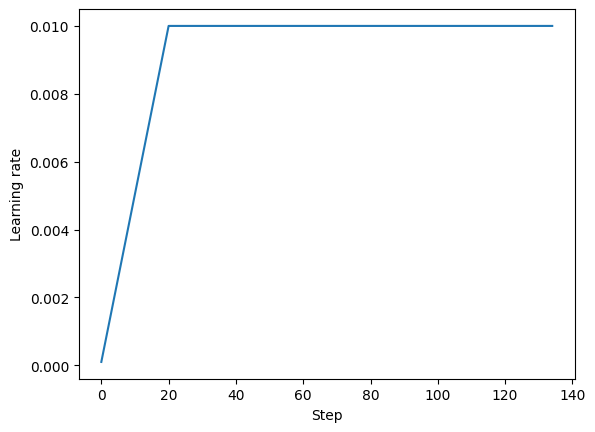

In [12]:
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs);
plt.show()

In [13]:
min_lr = 0.1 * initial_lr
track_lrs = []
lr_increment = (peak_lr - initial_lr) / warmup_steps
global_step = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        if global_step < warmup_steps:                    
            lr = initial_lr + global_step * lr_increment  
        else:                                               
            progress = ((global_step - warmup_steps) / 
                (total_training_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                1 + math.cos(math.pi * progress)
            )
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

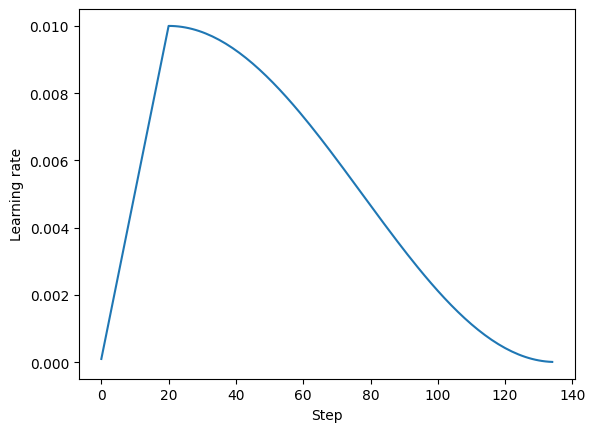

In [14]:
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs)
plt.show()

In [15]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
loss = calc_loss_batch(input_batch, target_batch, model, device)
loss.backward()

In [16]:
def find_highest_gradient(model):
    max_grad = None
    for param in model.parameters():
        if param.grad is not None:
            grad_values = param.grad.data.flatten()
            max_grad_param = grad_values.max()
            if max_grad is None or max_grad_param > max_grad:
                max_grad = max_grad_param
    return max_grad
print(find_highest_gradient(model))

tensor(0.0572, device='cuda:0')


In [17]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_highest_gradient(model))

tensor(0.0258, device='cuda:0')


## New Training

In [18]:
def train_model(model, train_loader, val_loader, optimizer, device,
        n_epochs, eval_freq, eval_iter, start_context, tokenizer,
        warmup_steps, initial_lr=3e-05, min_lr=1e-6):
    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1
    
    peak_lr = optimizer.param_groups[0]["lr"]  
    total_training_steps = len(train_loader) * n_epochs    
    lr_increment = (peak_lr - initial_lr) / warmup_steps   
    
    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1
            if global_step < warmup_steps:  
                lr = initial_lr + global_step * lr_increment  
            else:
                progress = ((global_step - warmup_steps) / 
                            (total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (
                    1 + math.cos(math.pi * progress))

            for param_group in optimizer.param_groups:  
                param_group["lr"] = lr
            track_lrs.append(lr)
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            
            if global_step > warmup_steps:        
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=1.0
                )
        
            optimizer.step() 
            tokens_seen += input_batch.numel()
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen, track_lrs

In [22]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
peak_lr = 5e-4
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
tokenizer = tiktoken.get_encoding("gpt2")

n_epochs = 10

train_losses, val_losses, tokens_seen, lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    tokenizer=tokenizer, warmup_steps=warmup_steps, 
    initial_lr=1e-5, min_lr=1e-5
)

Ep 1 (Iter 000000): Train loss 10.969, Val loss 10.938
Ep 1 (Iter 000005): Train loss 9.185, Val loss 9.301
Every effort moves you,,,. the   him of?" ,-- in.   the he, the theI.  in in  me.  in ", ofender." of. the; to  with, it the was, his
Ep 2 (Iter 000010): Train loss 7.342, Val loss 7.757
Ep 2 (Iter 000015): Train loss 6.045, Val loss 6.689
Every effort moves you " his." with a in me- had him I I me and his my with a." with was with it and said and he ":,-.  with  it on his that;,., and he that my" a
Ep 3 (Iter 000020): Train loss 5.975, Val loss 6.730
Ep 3 (Iter 000025): Train loss 5.526, Val loss 6.828
Every effort moves you. And I up say were his on one have in of of." it, his-- _!!--, his----and; he about was for about say, an ofburn, when St-- one. I the St, of
Ep 4 (Iter 000030): Train loss 6.113, Val loss 7.509
Ep 4 (Iter 000035): Train loss 5.086, Val loss 6.776
Every effort moves youis withisisburn through_"I felt-- It ais own's not an he had been " the Mrs have with it, 

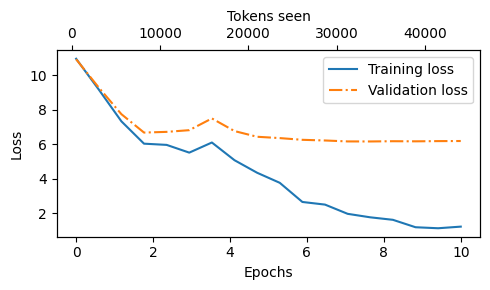

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                  
    ax2.plot(tokens_seen, train_losses, alpha=0)    
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, n_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)